In [ ]:
import sklearn
print(sklearn.__version__)  # має показати 1.3.0

1.6.1


In [ ]:
# Клітинка 2: Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_curve, auc)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Швидкий розподіл класів
print("Train class distribution:\n", train_df['upos'].value_counts(normalize=True))

Saving train.csv to train.csv
Saving test.csv to test.csv
Saving validation.csv to validation.csv
Train shape: (87369, 8)
Val shape: (10842, 8)
Test shape: (10955, 8)
Train class distribution:
 upos
NOUN     0.245453
PUNCT    0.173769
VERB     0.110062
ADJ      0.100848
ADP      0.083393
PRON     0.056370
ADV      0.051208
DET      0.039293
PROPN    0.037199
CCONJ    0.035173
PART     0.022857
SCONJ    0.022285
AUX      0.010496
NUM      0.010232
X        0.000847
INTJ     0.000515
Name: proportion, dtype: float64


In [ ]:
# Клітинка 5: Lab6 Baseline (LogReg + TF-IDF word(1,2) + token+lemma)
X_train = train_df['token'] + " " + train_df['lemma']
X_val = val_df['token'] + " " + val_df['lemma']
X_test = test_df['token'] + " " + test_df['lemma']

y_train = train_df['upos']
y_val = val_df['upos']
y_test = test_df['upos']

# TF-IDF
vectorizer_baseline = TfidfVectorizer(analyzer='word', ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer_baseline.fit_transform(X_train)
X_val_vec = vectorizer_baseline.transform(X_val)
X_test_vec = vectorizer_baseline.transform(X_test)

# Logistic Regression
lr_baseline = LogisticRegression(max_iter=200)
lr_baseline.fit(X_train_vec, y_train)

# Predictions
y_val_pred = lr_baseline.predict(X_val_vec)
y_test_pred = lr_baseline.predict(X_test_vec)

# Metrics
print("Baseline Lab6 - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Macro-F1:", f1_score(y_val, y_val_pred, average='macro'))
print(classification_report(y_val, y_val_pred))

Baseline Lab6 - Validation
Accuracy: 0.8121195351411179
Macro-F1: 0.7082044269051749
              precision    recall  f1-score   support

         ADJ       0.99      0.70      0.82      1062
         ADP       0.99      0.68      0.81       929
         ADV       0.97      0.85      0.90       536
         AUX       0.94      0.74      0.82        99
       CCONJ       0.98      0.33      0.49       322
         DET       0.99      0.97      0.98       396
        INTJ       0.00      0.00      0.00         0
        NOUN       1.00      0.83      0.91      2647
         NUM       0.78      0.42      0.55       136
        PART       0.99      0.78      0.87       259
        PRON       0.98      0.79      0.88       521
       PROPN       1.00      0.61      0.76       455
       PUNCT       0.51      1.00      0.68      2034
       SCONJ       0.92      0.99      0.95       206
        VERB       0.98      0.84      0.90      1202
           X       0.00      0.00      0.00       

In [ ]:
# Клітинка 6: Linear SVM Word baseline
vectorizer_word = TfidfVectorizer(analyzer='word', ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer_word.fit_transform(X_train)
X_val_vec = vectorizer_word.transform(X_val)
X_test_vec = vectorizer_word.transform(X_test)

svm_word = LinearSVC(C=1.0)
svm_word.fit(X_train_vec, y_train)

y_val_pred_svm_word = svm_word.predict(X_val_vec)
y_test_pred_svm_word = svm_word.predict(X_test_vec)

print("LinearSVC Word - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm_word))
print("Macro-F1:", f1_score(y_val, y_val_pred_svm_word, average='macro'))

LinearSVC Word - Validation
Accuracy: 0.8558384061981185
Macro-F1: 0.7447160353144606


In [16]:
# Клітинка 7: Linear SVM Word + Char ngrams
vectorizer_char = TfidfVectorizer(analyzer='char', ngram_range=(3,5), sublinear_tf=True)
X_train_char_vec = vectorizer_char.fit_transform(X_train)
X_val_char_vec = vectorizer_char.transform(X_val)
X_test_char_vec = vectorizer_char.transform(X_test)

svm_char = LinearSVC(C=1.0)
svm_char.fit(X_train_char_vec, y_train)

y_val_pred_svm_char = svm_char.predict(X_val_char_vec)
y_test_pred_svm_char = svm_char.predict(X_test_char_vec)

print("LinearSVC Word+Char - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm_char))
print("Macro-F1:", f1_score(y_val, y_val_pred_svm_char, average='macro'))

LinearSVC Word+Char - Validation
Accuracy: 0.9730676996864047
Macro-F1: 0.8349481256251869


In [17]:
# Клітинка 8: LinearSVC + class_weight='balanced'
svm_char_balanced = LinearSVC(C=1.0, class_weight='balanced')
svm_char_balanced.fit(X_train_char_vec, y_train)

y_val_pred_bal = svm_char_balanced.predict(X_val_char_vec)
print("LinearSVC Word+Char + class_weight='balanced' - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_bal))
print("Macro-F1:", f1_score(y_val, y_val_pred_bal, average='macro'))

LinearSVC Word+Char + class_weight='balanced' - Validation
Accuracy: 0.9712230215827338
Macro-F1: 0.83639466699663


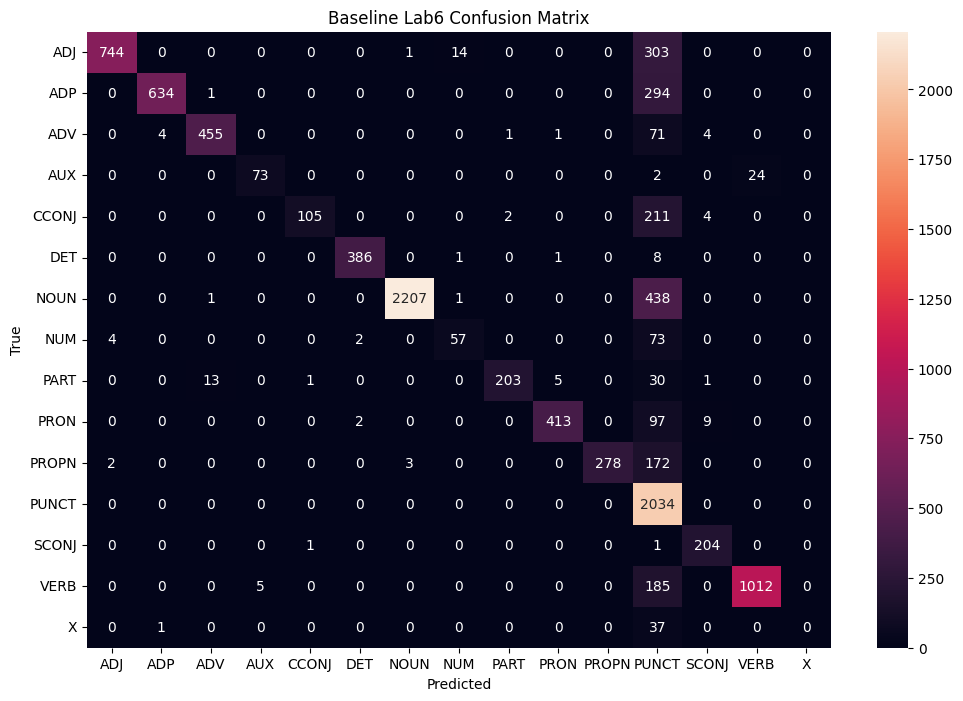

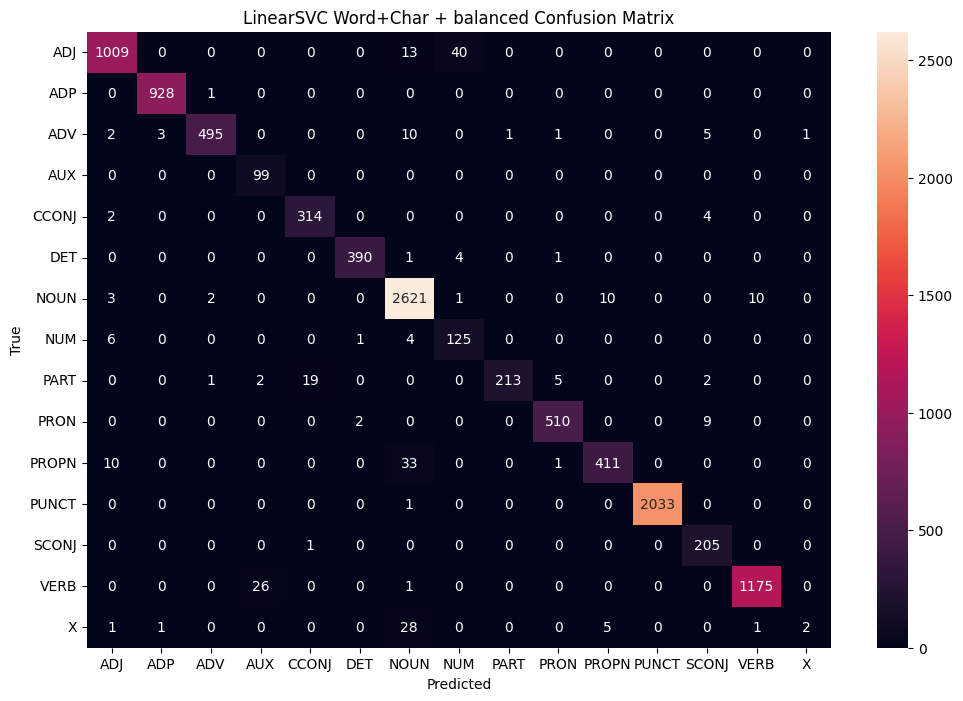

In [18]:
# Клітинка 9: Confusion matrix for Lab6 vs best SVM
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(12,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

# Baseline Lab6
plot_conf_matrix(y_val, y_val_pred, "Baseline Lab6 Confusion Matrix")

# Best SVM (Word+Char+balanced)
plot_conf_matrix(y_val, y_val_pred_bal, "LinearSVC Word+Char + balanced Confusion Matrix")

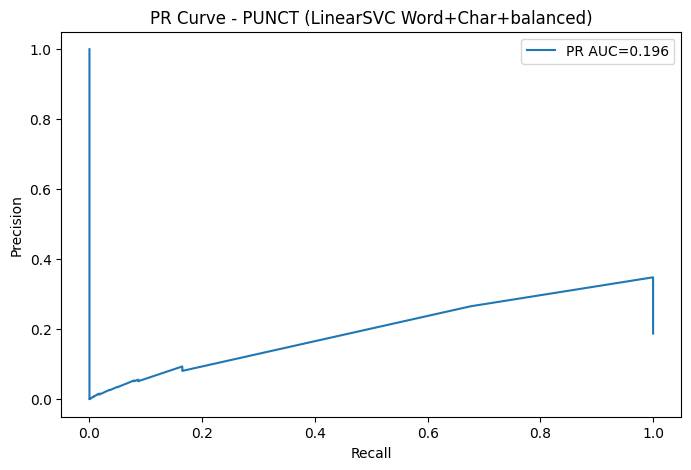

Chosen threshold for PUNCT: -1.0001195605494253


In [19]:
# Клітинка 10: PR-curve for PUNCT
from sklearn.preprocessing import label_binarize

classes = y_train.unique()
y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin = label_binarize(y_val, classes=classes)

punct_idx = list(classes).index('PUNCT')

# Decision function scores
scores_val = svm_char_balanced.decision_function(X_val_char_vec)
punct_scores = scores_val[:, punct_idx]
punct_true = y_val_bin[:, punct_idx]

precision, recall, thresholds = precision_recall_curve(punct_true, punct_scores)
auc_pr = auc(recall, precision)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, label=f'PR AUC={auc_pr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve - PUNCT (LinearSVC Word+Char+balanced)')
plt.legend()
plt.show()

# Example: choose threshold that balances precision/recall
thresh_idx = np.argmax(precision + recall)  # simple balance
best_threshold = thresholds[thresh_idx]
print("Chosen threshold for PUNCT:", best_threshold)

In [20]:
# Клітинка 11: Error analysis
val_df['pred'] = y_val_pred_bal
errors = val_df[val_df['upos'] != val_df['pred']]
errors_sample = errors.sample(10, random_state=42)

for idx, row in errors_sample.iterrows():
    print(f"Sent {row['sent_id']} | Token: {row['token']} | Gold: {row['upos']} | Pred: {row['pred']}")

Sent ParlaMint-UA_2022-01-25-m0.u160.p1.lang1.s2 | Token: 3 | Gold: ADJ | Pred: NUM
Sent ParlaMint-UA_2022-01-25-m0.u92.p2.lang1.s4 | Token: так | Gold: ADV | Pred: INTJ
Sent ParlaMint-UA_2022-01-25-m0.u110.p2.lang1.s4 | Token: Туреччини | Gold: PROPN | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u112.p1.lang1.s2 | Token: 6199 | Gold: NUM | Pred: ADJ
Sent ParlaMint-UA_2022-01-25-m0.u99.p12.lang1.s2 | Token: Будемо | Gold: VERB | Pred: AUX
Sent ParlaMint-UA_2022-01-25-m0.u115.p1.lang1.s1 | Token: головуючий | Gold: ADJ | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u116.p1.lang1.s1 | Token: Забродському | Gold: PROPN | Pred: ADJ
Sent ParlaMint-UA_2022-01-25-m0.u143.p2.lang1.s7 | Token: книгорозповсюджувачам | Gold: NOUN | Pred: PROPN
Sent ParlaMint-UA_2022-01-25-m0.u172.p4.lang1.s5 | Token: position | Gold: X | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u106.p2.lang1.s6 | Token: і | Gold: PART | Pred: CCONJ


In [21]:
# Клітинка 12: Generate audit_summary_lab7.md
audit_text = f"""
Lab7 - LinearSVC + Char-ngrams + Imbalance

Task: POS tagging (token classification)
Baseline Lab6: TF-IDF word(1,2) + Logistic Regression
SVM models tested:
 - LinearSVC Word(1,2)
 - LinearSVC Word+Char(3-5)
 - LinearSVC Word+Char + class_weight='balanced'

Best result (Validation):
 - Accuracy: {accuracy_score(y_val, y_val_pred_bal):.4f}
 - Macro-F1: {f1_score(y_val, y_val_pred_bal, average='macro'):.4f}

Char-ngrams helped: Yes
Class_weight='balanced' helped: Yes
Threshold for PUNCT selected: {best_threshold:.4f}
Most frequent errors: short tokens, noisy tokens, class overlap (ADJ/PROPN)
"""

with open("/content/audit_summary_lab7.md", "w", encoding='utf-8') as f:
    f.write(audit_text)

print("audit_summary_lab7.md generated!")

audit_summary_lab7.md generated!


Validation Metrics Comparison


,Model,Features,Class_weight,Accuracy,Macro-F1
0,LogReg Baseline (Lab6),"word(1,2)",no,0.812120,0.708204
1,LinearSVC Word,"word(1,2)",no,0.855838,0.744716
2,LinearSVC Word+Char,"word+char(3,5)",balanced,0.971223,0.836395


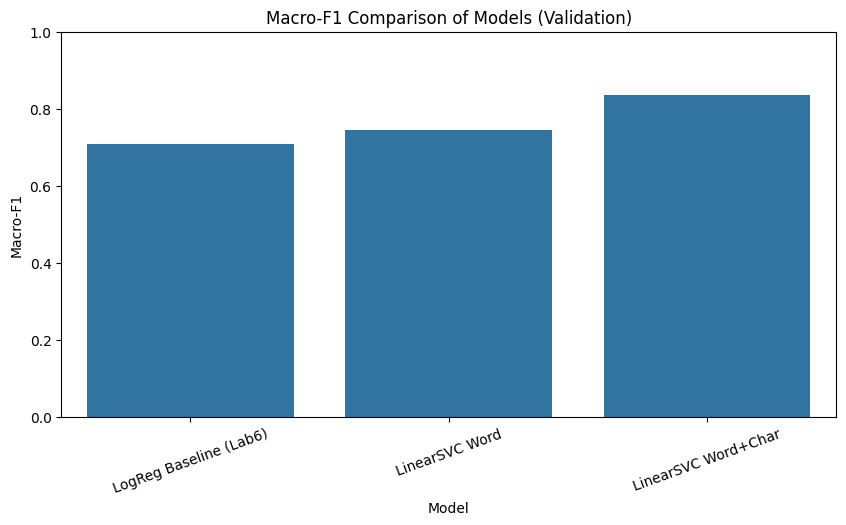

In [22]:
# Клітинка 13: Compare all models in a table
results = []

# Lab6 baseline
results.append({
    "Model": "LogReg Baseline (Lab6)",
    "Features": "word(1,2)",
    "Class_weight": "no",
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Macro-F1": f1_score(y_val, y_val_pred, average='macro')
})

# LinearSVC word
results.append({
    "Model": "LinearSVC Word",
    "Features": "word(1,2)",
    "Class_weight": "no",
    "Accuracy": accuracy_score(y_val, y_val_pred_svm_word),
    "Macro-F1": f1_score(y_val, y_val_pred_svm_word, average='macro')
})

# LinearSVC word + char + balanced
results.append({
    "Model": "LinearSVC Word+Char",
    "Features": "word+char(3,5)",
    "Class_weight": "balanced",
    "Accuracy": accuracy_score(y_val, y_val_pred_bal),
    "Macro-F1": f1_score(y_val, y_val_pred_bal, average='macro')
})

results_df = pd.DataFrame(results)
results_df = results_df[["Model","Features","Class_weight","Accuracy","Macro-F1"]]

# Display nicely
print("Validation Metrics Comparison")
display(results_df)

# Optional: barplot for visual comparison
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Macro-F1", data=results_df)
plt.title("Macro-F1 Comparison of Models (Validation)")
plt.ylabel("Macro-F1")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()